# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, LeaveOneOut, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, RidgeCV, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load Dataset

In [4]:
df = pd.read_csv('house price.csv')
df.head(3)

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242


# Basic Dataset Understanding

In [6]:
df.shape

(3800, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


In [8]:
df.describe().round(2)

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00,3800.00
mean,201900.50,1716.93,3.43,2.92,6.50,22.54,13.09,0.55,0.47,4.24,20719397.17
std,1097.11,583.00,1.36,1.13,1.77,12.33,6.54,0.50,0.50,2.05,8707465.39
min,200001.00,500.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.50,1506126.00
25%,200950.75,1322.00,2.00,2.00,5.30,14.00,8.50,0.00,0.00,2.81,14468946.50
50%,201900.50,1700.50,3.00,3.00,6.50,20.00,13.00,1.00,0.00,4.22,19891801.50
75%,202850.25,2105.00,4.00,4.00,7.70,29.00,17.50,1.00,1.00,5.65,25960617.50
max,203800.00,3776.00,7.00,6.00,10.00,80.00,38.70,1.00,1.00,12.00,59303146.00


In [9]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

In [10]:
df.duplicated().sum()

0

# Exploratory Data Analysis (EDA)

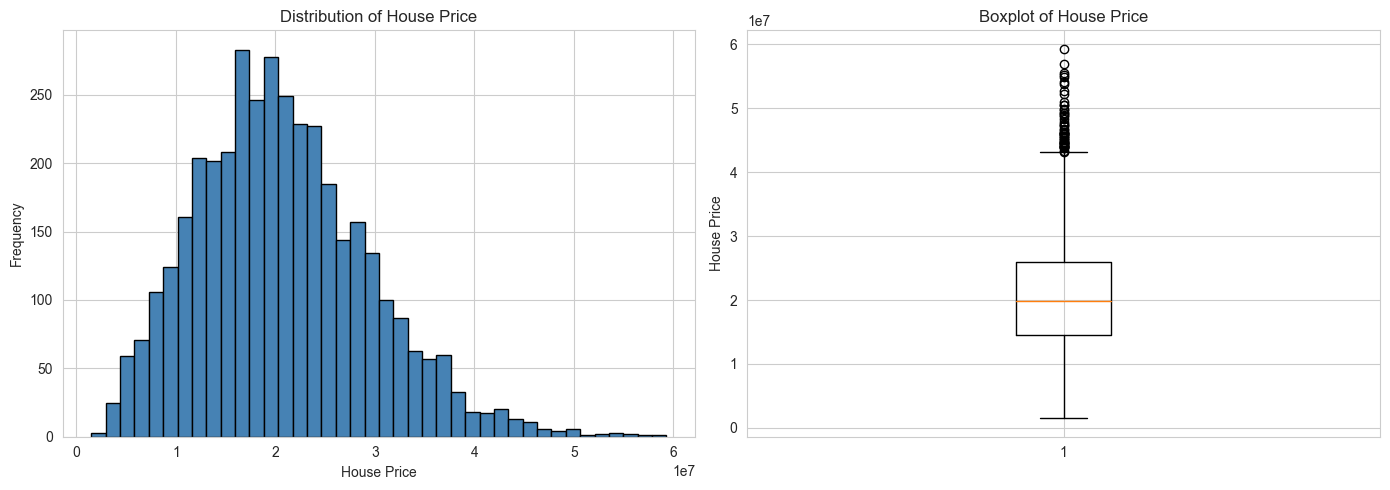

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['house_price_inr'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of House Price')
axes[0].set_xlabel('House Price')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['house_price_inr'], vert=True)
axes[1].set_title('Boxplot of House Price')
axes[1].set_ylabel('House Price')

plt.tight_layout()
plt.savefig('plot_house_price_dist.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:**  
- The house price distribution looks roughly normal with a slight right skew 
- There are a few high-value outliers visible in the boxplot

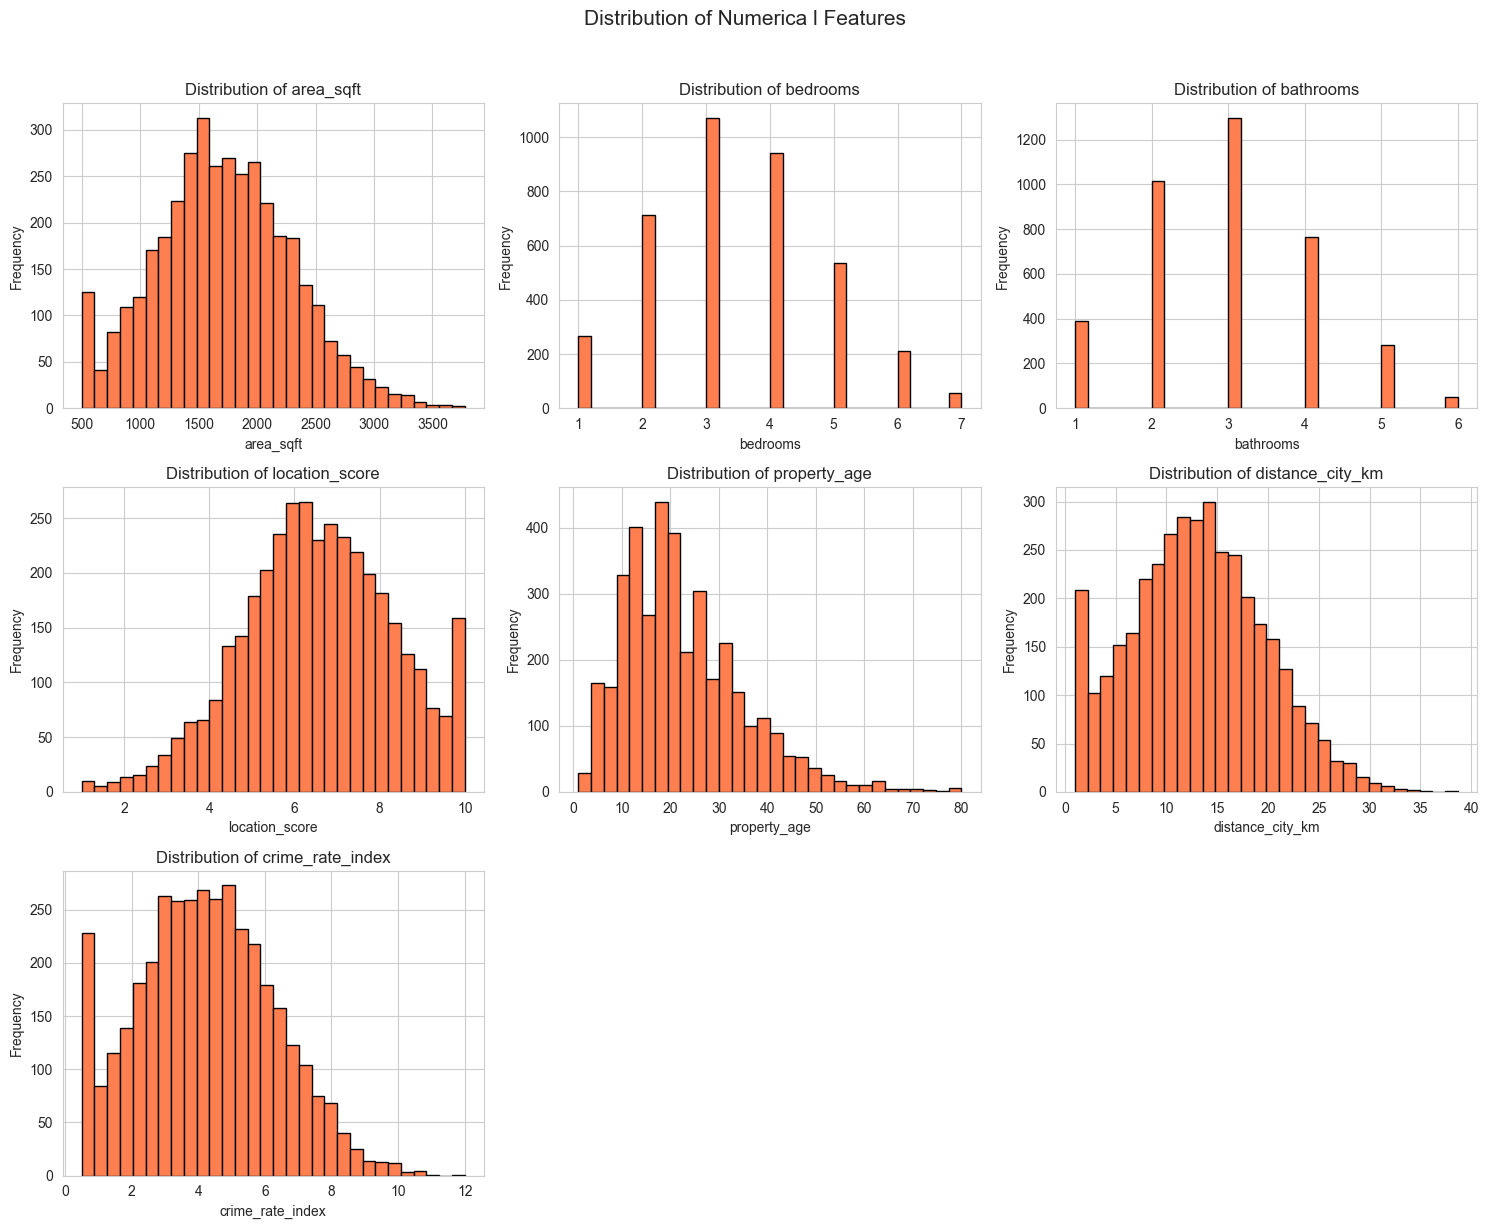

In [14]:
num_cols = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'crime_rate_index']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='coral', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

for j in range(len(num_cols), len(axes)):    # Hide empty subplots
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerica l Features', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('plot_feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:**  
- `area_sqft` is fairly uniformly distributed between 500 and 3800 sqft.
- `bedrooms` and `bathrooms` have discrete distributions with 2 to 6 bedrooms being most common.
- `property_age` has a relatively uniform spread.
- `crime_rate_index` shows a slightly right-skewed distribution.
- `distance_city_km` ranges widely, indicating properties from both central and suburban areas.

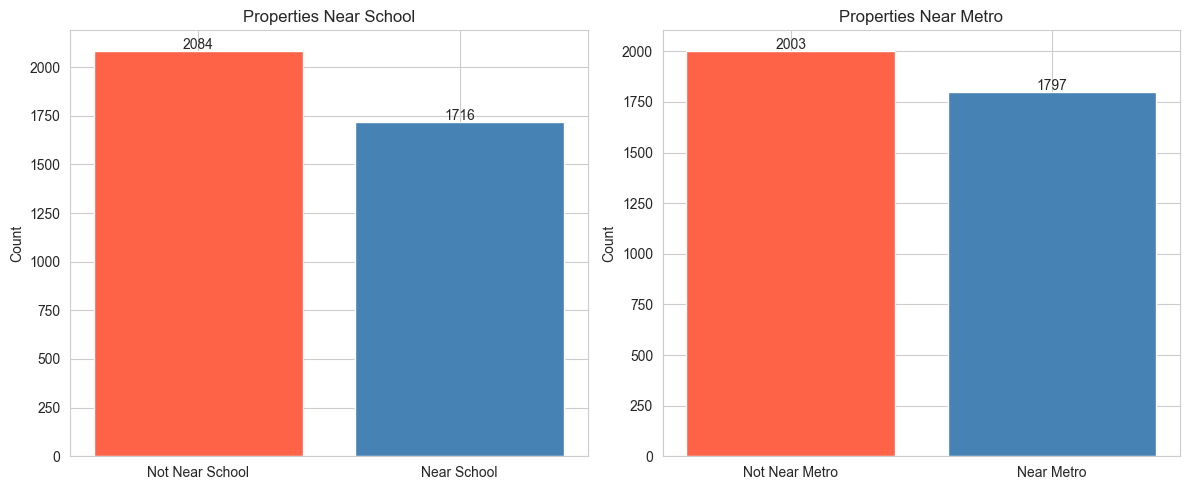

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

near_school_counts = df['near_school'].value_counts()
axes[0].bar(['Not Near School', 'Near School'], near_school_counts.values, color=['tomato', 'steelblue'])
axes[0].set_title('Properties Near School')
axes[0].set_ylabel('Count')
for i, v in enumerate(near_school_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center')

near_metro_counts = df['near_metro'].value_counts()
axes[1].bar(['Not Near Metro', 'Near Metro'], near_metro_counts.values, color=['tomato', 'steelblue'])
axes[1].set_title('Properties Near Metro')
axes[1].set_ylabel('Count')
for i, v in enumerate(near_metro_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.savefig('plot_binary_features.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:**  
The dataset has a roughly balanced distribution of properties near and not near schools and metro stations. This is good as it means both categories are well represented for training.

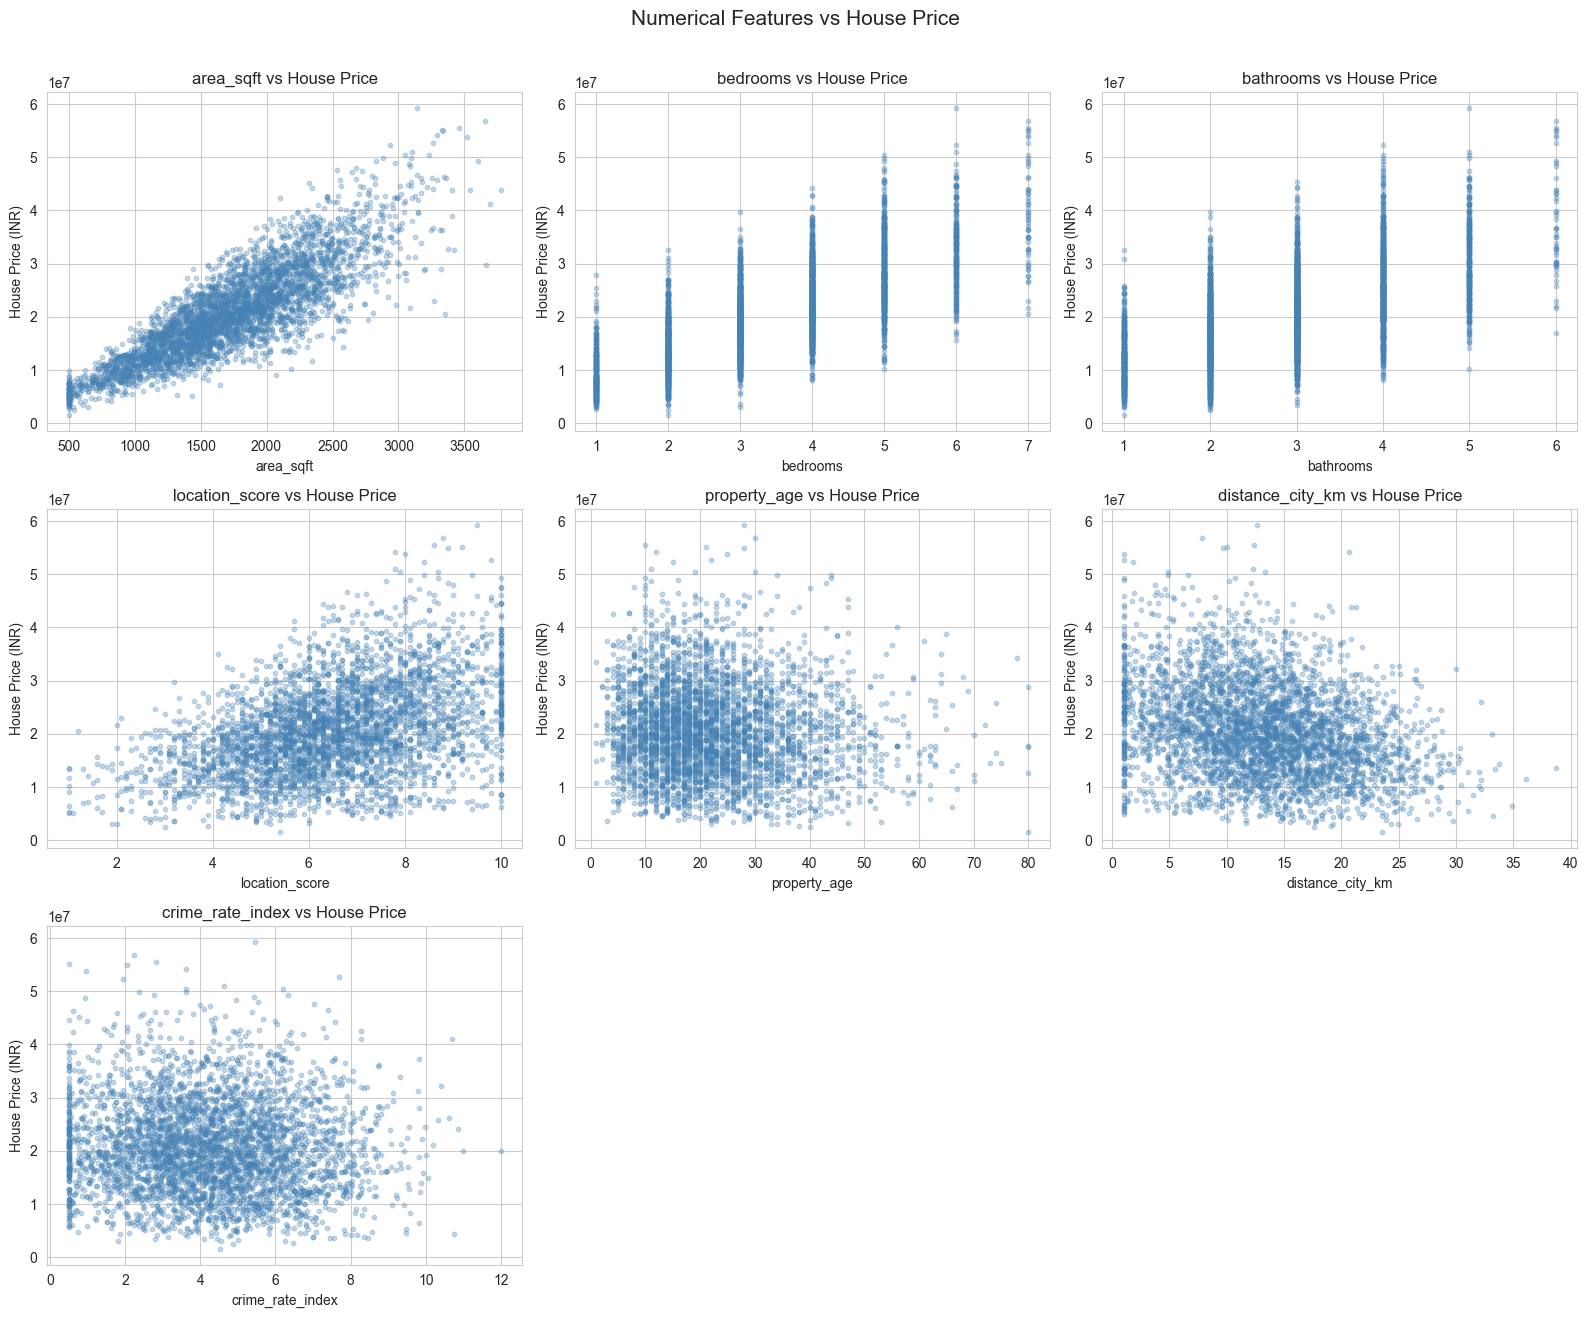

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(df[col], df['house_price_inr'], alpha=0.3, color='steelblue', s=10)
    axes[i].set_title(f'{col} vs House Price')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('House Price (INR)')
    
for j in range(len(num_cols), len(axes)):      # Hide empty subplots
    axes[j].set_visible(False)

plt.suptitle('Numerical Features vs House Price', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('plot_bivariate_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:**  
- `area_sqft` shows a clear positive correlation with house price. Larger properties cost more.
- `location_score` also shows a positive trend. Better locations have higher prices.
- `distance_city_km` seems to have a slight negative relationship. Properties closer to the city tend to be pricier.
- `crime_rate_index` might show a negative impact on price as expected.
- `bedrooms` and `bathrooms` also positively correlate with price.

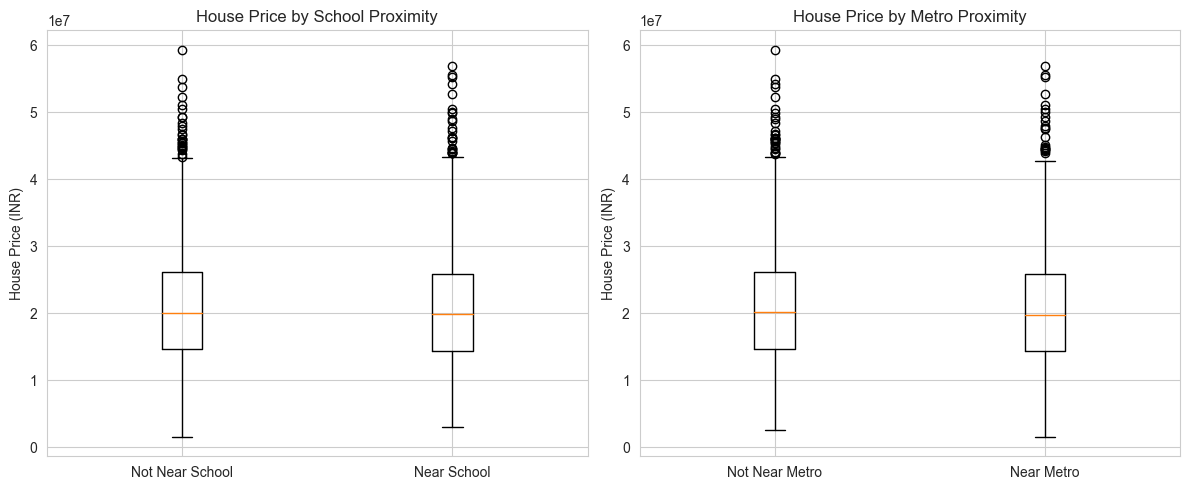

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

school_groups = [df[df['near_school']==0]['house_price_inr'], df[df['near_school']==1]['house_price_inr']]
axes[0].boxplot(school_groups, labels=['Not Near School', 'Near School'])
axes[0].set_title('House Price by School Proximity')
axes[0].set_ylabel('House Price (INR)')

metro_groups = [df[df['near_metro']==0]['house_price_inr'], df[df['near_metro']==1]['house_price_inr']]
axes[1].boxplot(metro_groups, labels=['Not Near Metro', 'Near Metro'])
axes[1].set_title('House Price by Metro Proximity')
axes[1].set_ylabel('House Price (INR)')

plt.tight_layout()
plt.savefig('plot_binary_vs_price.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:**  
- Properties located near schools and metro stations have slightly higher median house prices compared to those that are not nearby, indicating that accessibility and nearby amenities positively influence property values.

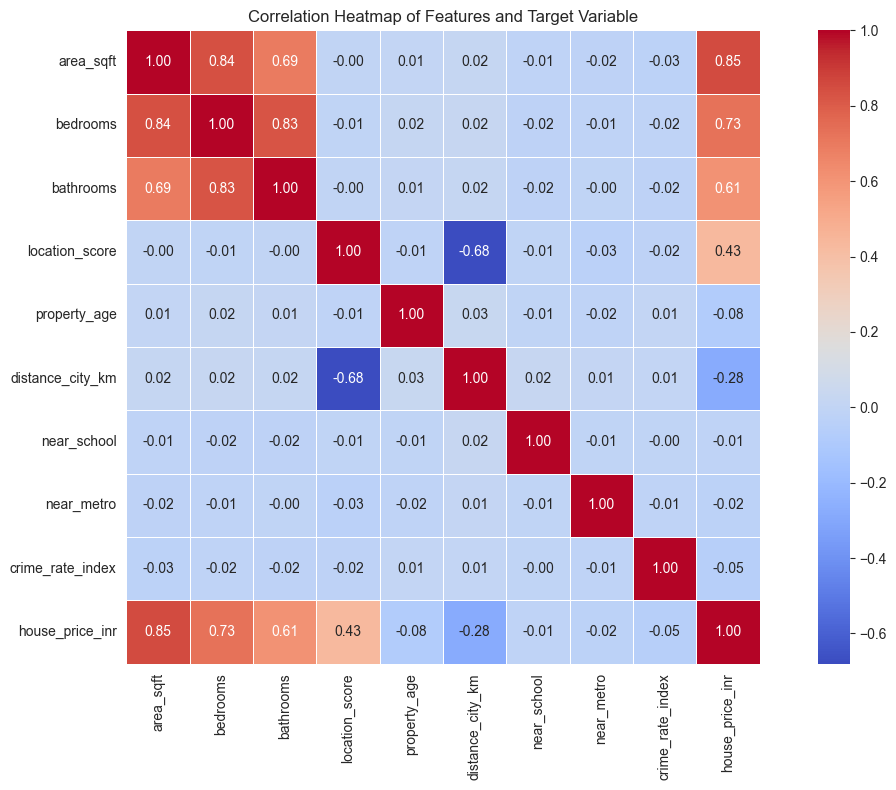

In [22]:
corr_cols = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index', 'house_price_inr']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Features and Target Variable')
plt.tight_layout()
plt.savefig('plot_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:**  
- `area_sqft` has the highest positive correlation with `house_price_inr`.
- `location_score` also positively correlates with price.
- `crime_rate_index` and `distance_city_km` have negative correlations with price as expected.
- `bedrooms` and `bathrooms` are highly correlated with each other (multicollinearity possible).
- `property_age` shows some negative relationship - older homes might be cheaper.

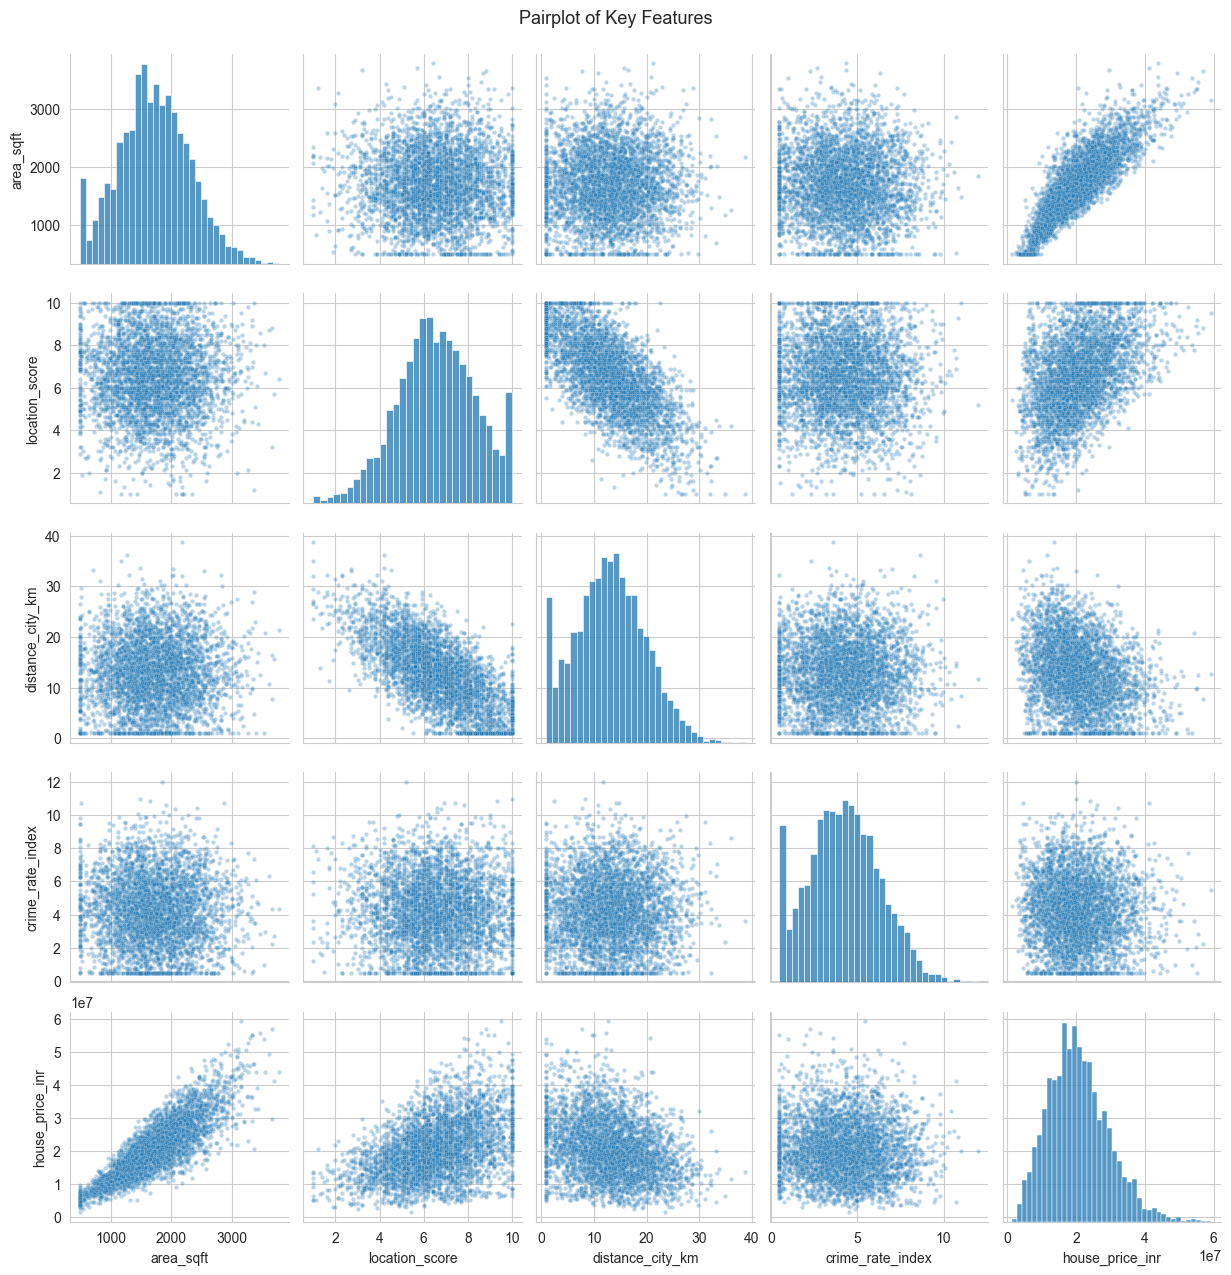

In [24]:
selected = ['area_sqft', 'location_score', 'distance_city_km', 'crime_rate_index', 'house_price_inr']
sns.pairplot(df[selected], diag_kind='hist', plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=13)
plt.savefig('plot_pairplot.png', dpi=80, bbox_inches='tight')
plt.show()

# Data Preprocessing

In [26]:
df_clean = df.copy()

# feature engineering 
df_clean['sale_date'] = pd.to_datetime(df_clean['sale_date'])
df_clean['sale_year'] = df_clean['sale_date'].dt.year
df_clean['sale_month'] = df_clean['sale_date'].dt.month
df_clean.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr,sale_year,sale_month
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898,2014,1
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893,2019,12
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242,2016,10
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310,2013,3
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429,2013,7


In [27]:
df_clean.drop(['property_id', 'sale_date'], axis=1, inplace=True)  # drop not important columns
df_clean.columns

Index(['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age',
       'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index',
       'house_price_inr', 'sale_year', 'sale_month'],
      dtype='object')

In [28]:
df_clean.shape

(3800, 12)

In [29]:
Q1 = df_clean['house_price_inr'].quantile(0.25)      # handling outliers
Q3 = df_clean['house_price_inr'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Rows before removing outliers: {df_clean.shape[0]}")

df_clean = df_clean[(df_clean['house_price_inr'] >= lower_bound) & (df_clean['house_price_inr'] <= upper_bound)]

print(f"Rows after removing outliers: {df_clean.shape[0]}")

Lower Bound: -2768560.00
Upper Bound: 43198124.00
Rows before removing outliers: 3800
Rows after removing outliers: 3748


# Feature Selection and Train-Test Split

In [31]:
X = df_clean.drop('house_price_inr', axis=1)
y = df_clean['house_price_inr']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling

In [34]:
scaler = StandardScaler()    # required for Ridge, Lasso ,SVR  not for tree's model

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)   

X_train_scaled.shape

(2998, 11)

# Ridge Regression with Cross-Validation for Alpha Tuning

In [36]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]   # find best alphga value for ridge

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

print("Best alpha for Ridge:", ridge_cv.alpha_)

Best alpha for Ridge: 1.0


In [37]:
best_alpha_ridge = ridge_cv.alpha_

ridge_model = Ridge(alpha=best_alpha_ridge)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge_train = ridge_model.predict(X_train_scaled)
y_pred_ridge_test = ridge_model.predict(X_test_scaled)

ridge_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_ridge_train))
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))
ridge_train_r2 = r2_score(y_train, y_pred_ridge_train)
ridge_test_r2 = r2_score(y_test, y_pred_ridge_test)

print(f"Ridge Regression Results (alpha={best_alpha_ridge}):")
print(f"Training RMSE: {ridge_train_rmse:,.2f}")
print(f"Testing RMSE:  {ridge_test_rmse:,.2f}")
print(f"Training R2:   {ridge_train_r2:.4f}")
print(f"Testing R2:    {ridge_test_r2:.4f}")

Ridge Regression Results (alpha=1.0):
Training RMSE: 2,409,867.66
Testing RMSE:  2,219,684.78
Training R2:   0.9133
Testing R2:    0.9216


# Lasso Regression with Cross-Validation for Alpha Tuning

In [39]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)       # find best alphga value for lasso
lasso_cv.fit(X_train_scaled, y_train)

print("Best alpha for Lasso:", lasso_cv.alpha_)

Best alpha for Lasso: 1000.0


In [40]:
best_alpha_lasso = lasso_cv.alpha_
lasso_model = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso_train = lasso_model.predict(X_train_scaled)
y_pred_lasso_test = lasso_model.predict(X_test_scaled)

lasso_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_lasso_train))
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))
lasso_train_r2 = r2_score(y_train, y_pred_lasso_train)
lasso_test_r2 = r2_score(y_test, y_pred_lasso_test)

print(f"Lasso Regression Results (alpha={best_alpha_lasso}):")
print(f"Training RMSE: {lasso_train_rmse:,.2f}")
print(f"Testing RMSE:  {lasso_test_rmse:,.2f}")
print(f"Training R2:   {lasso_train_r2:.4f}")
print(f"Testing R2:    {lasso_test_r2:.4f}")

Lasso Regression Results (alpha=1000.0):
Training RMSE: 2,409,866.10
Testing RMSE:  2,219,651.07
Training R2:   0.9133
Testing R2:    0.9216


# Comparing Ridge and Lasso - Feature Coefficient Behavior

In [42]:
feature_names = X.columns.tolist()

coef_df = pd.DataFrame({ 'Feature': feature_names, 'Ridge Coefficient': ridge_model.coef_, 'Lasso Coefficient': lasso_model.coef_})
print(coef_df.to_string(index=False))

         Feature  Ridge Coefficient  Lasso Coefficient
       area_sqft       6.590370e+06       6.595309e+06
        bedrooms       3.417623e+05       3.386796e+05
       bathrooms       2.008919e+05       1.991143e+05
  location_score       3.594238e+06       3.595810e+06
    property_age      -6.785344e+05      -6.777621e+05
distance_city_km      -2.022117e+04      -1.819038e+04
     near_school       2.621764e+04       2.515268e+04
      near_metro       8.276296e+04       8.186393e+04
crime_rate_index      -1.894415e+05      -1.884962e+05
       sale_year       2.589679e+05       2.581277e+05
      sale_month      -7.920241e+03      -6.949320e+03


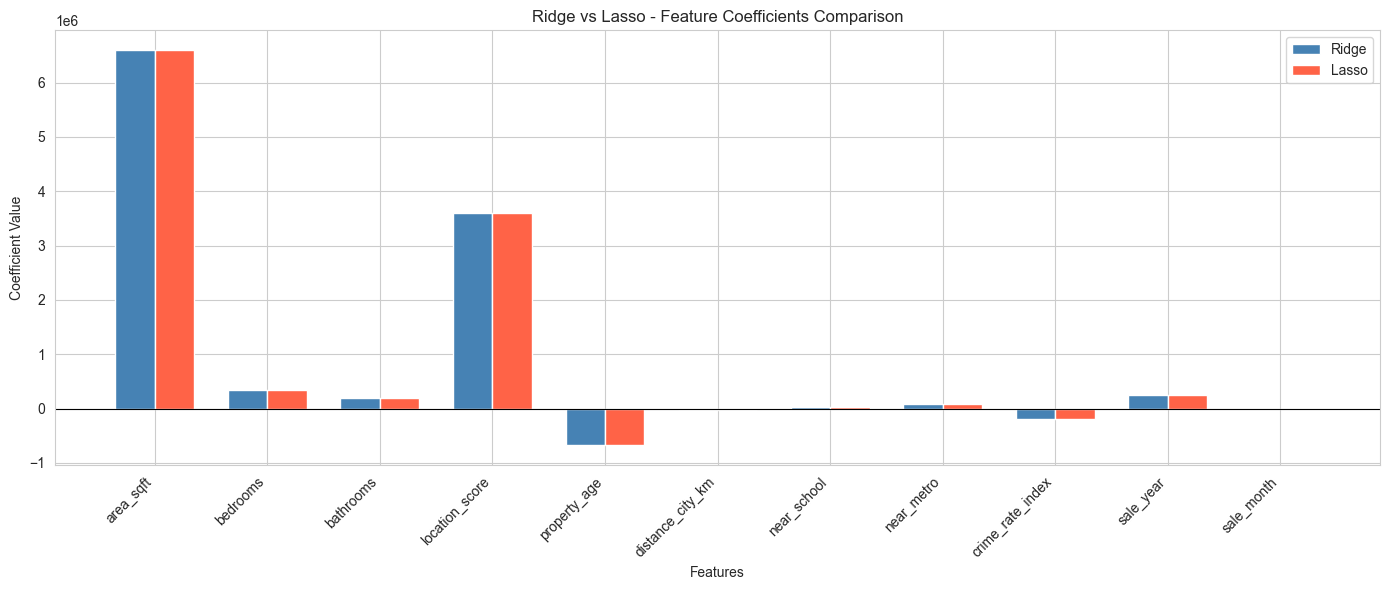

Features zeroed out by Lasso: []


In [43]:
x_pos = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x_pos - width/2, ridge_model.coef_, width, label='Ridge', color='steelblue')
ax.bar(x_pos + width/2, lasso_model.coef_, width, label='Lasso', color='tomato')

ax.set_xlabel('Features')
ax.set_ylabel('Coefficient Value')
ax.set_title('Ridge vs Lasso - Feature Coefficients Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('plot_ridge_lasso_coef.png', dpi=100, bbox_inches='tight')
plt.show()

print("Features zeroed out by Lasso:", [feature_names[i] for i, c in enumerate(lasso_model.coef_) if c == 0])

**Observation:**  
- Ridge shrinks all coefficients but keeps them non-zero.
- Lasso eliminates some features completely by setting their coefficients to zero.
- Both models agree that `area_sqft` and `location_score` are the most important features.
- The features that Lasso zeros out are the less important ones for predicting house price.

# Cross-Validation 

In [46]:
ridge_for_cv = Ridge(alpha=best_alpha_ridge)      # Using Ridge model for CV comparison

# 1. K-Fold Cross-Validation 
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(ridge_for_cv, X_train_scaled, y_train, cv=kfold, scoring='r2')
print("K-Fold CV (R2) :", np.round(kfold_scores, 4))
print(f"Mean R2: {kfold_scores.mean():.4f}, Std: {kfold_scores.std():.4f}")

K-Fold CV (R2) : [0.9205 0.8906 0.9171 0.907  0.9236]
Mean R2: 0.9118, Std: 0.0120


In [47]:
# 2. Stratified K-Fold 
y_binned = pd.cut(y_train, bins=5, labels=False)

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skfold_scores = cross_val_score(ridge_for_cv, X_train_scaled, y_train, cv=skfold.split(X_train_scaled, y_binned), scoring='r2')
print("Stratified K-Fold CV (R2) :", np.round(skfold_scores, 4))
print(f"Mean R2: {skfold_scores.mean():.4f}, Std: {skfold_scores.std():.4f}")

Stratified K-Fold CV (R2) : [0.9206 0.9116 0.9123 0.9086 0.9102]
Mean R2: 0.9127, Std: 0.0042


In [48]:
# 3. Leave-One-Out Cross-Validation 
print("Running LOOCV on a sample (first 200 rows) - this may take a moment...")
X_sample = X_train_scaled[:200]
y_sample = y_train.values[:200]

loo = LeaveOneOut()
loo_scores = cross_val_score(ridge_for_cv, X_sample, y_sample, cv=loo, scoring='r2')
print(f"LOOCV Mean R2: {loo_scores.mean():.4f}, Std: {loo_scores.std():.4f}")

Running LOOCV on a sample (first 200 rows) - this may take a moment...
LOOCV Mean R2: nan, Std: nan


In [49]:
# 4. Time Series Split 
X_train_ts = X_train.copy()
X_train_ts_sorted = X_train_ts.sort_values('sale_year')
y_train_ts_sorted = y_train.loc[X_train_ts_sorted.index]

X_train_ts_scaled = scaler.fit_transform(X_train_ts_sorted)

tss = TimeSeriesSplit(n_splits=5)
tss_scores = cross_val_score(ridge_for_cv, X_train_ts_scaled, y_train_ts_sorted, cv=tss, scoring='r2')
print("Time Series Split (R2) :", np.round(tss_scores, 4))
print(f"Mean R2: {tss_scores.mean():.4f}, Std: {tss_scores.std():.4f}")

Time Series Split (R2) : [0.9017 0.9129 0.9189 0.9047 0.9197]
Mean R2: 0.9116, Std: 0.0073


In [50]:
# Comparing all 
cv_results = { 'K-Fold': kfold_scores, 'Stratified K-Fold': skfold_scores, 'Time Series Split': tss_scores}

print("CV Strategy Comparison:")
print(f"{'Strategy':<25} {'Mean R2':>10} {'Std Dev':>10}")
print("-" * 50)

for strategy, scores in cv_results.items():
    print(f"{strategy:<25} {scores.mean():>10.4f} {scores.std():>10.4f}")
print(f"{'LOOCV (sample)':<25} {loo_scores.mean():>10.4f} {loo_scores.std():>10.4f}")

CV Strategy Comparison:
Strategy                     Mean R2    Std Dev
--------------------------------------------------
K-Fold                        0.9118     0.0120
Stratified K-Fold             0.9127     0.0042
Time Series Split             0.9116     0.0073
LOOCV (sample)                   nan        nan


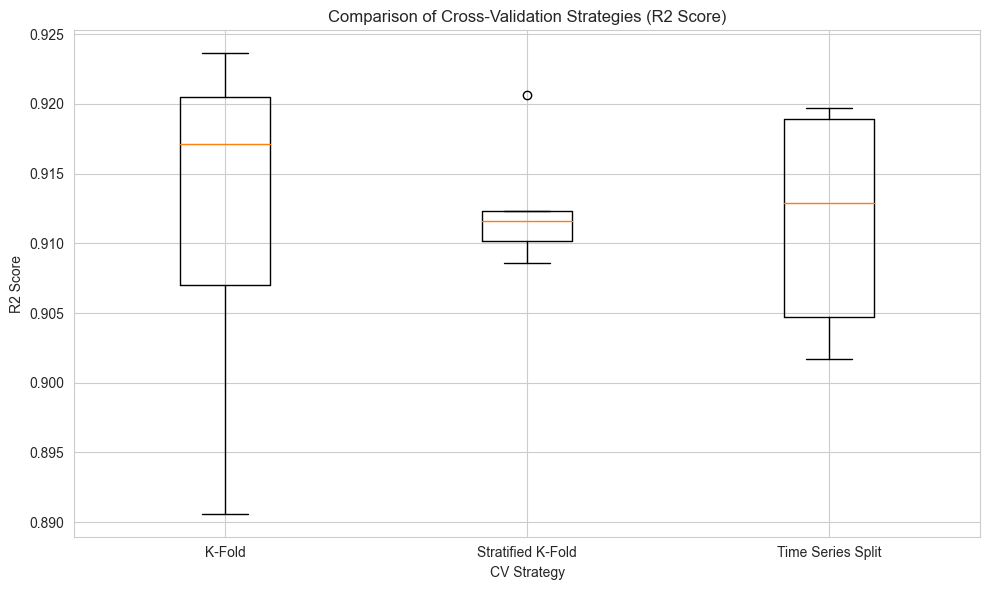

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([kfold_scores, skfold_scores, tss_scores], labels=['K-Fold', 'Stratified K-Fold', 'Time Series Split'])
ax.set_title('Comparison of Cross-Validation Strategies (R2 Score)')
ax.set_ylabel('R2 Score')
ax.set_xlabel('CV Strategy')
plt.tight_layout()
plt.savefig('plot_cv_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:**  
- K-Fold and Stratified K-Fold give consistent results with low standard deviation.
- Time Series Split shows variation across folds because earlier time periods have less training data.
- For this dataset, K-Fold with 5 folds is a good balance between accuracy and speed.

In [53]:
# Decision Tree
dt_default = DecisionTreeRegressor(random_state=42)   # defualt decision tree
dt_default.fit(X_train, y_train)

y_pred_dt_train_default = dt_default.predict(X_train)
y_pred_dt_test_default = dt_default.predict(X_test)

print("Decision Tree (No Depth Limit):")
print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_dt_train_default)):,.2f}")
print(f"Testing RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_dt_test_default)):,.2f}")
print(f"Training R2:   {r2_score(y_train, y_pred_dt_train_default):.4f}")
print(f"Testing R2:    {r2_score(y_test, y_pred_dt_test_default):.4f}")
print(f"Tree Depth:    {dt_default.get_depth()}")

Decision Tree (No Depth Limit):
Training RMSE: 0.00
Testing RMSE:  3,017,696.96
Training R2:   1.0000
Testing R2:    0.8551
Tree Depth:    22


In [54]:
# using hyperparameters
dt_controlled = DecisionTreeRegressor(max_depth=8, min_samples_split=20,  min_samples_leaf=10, random_state=42)
dt_controlled.fit(X_train, y_train)

y_pred_dt_train = dt_controlled.predict(X_train)
y_pred_dt_test = dt_controlled.predict(X_test)

dt_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_dt_train))
dt_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt_test))
dt_train_r2 = r2_score(y_train, y_pred_dt_train)
dt_test_r2 = r2_score(y_test, y_pred_dt_test)

print("Decision Tree (max_depth=8, min_samples_split=20, min_samples_leaf=10):")
print(f"Training RMSE: {dt_train_rmse:,.2f}")
print(f"Testing RMSE:  {dt_test_rmse:,.2f}")
print(f"Training R2:   {dt_train_r2:.4f}")
print(f"Testing R2:    {dt_test_r2:.4f}")

Decision Tree (max_depth=8, min_samples_split=20, min_samples_leaf=10):
Training RMSE: 2,018,329.68
Testing RMSE:  2,452,307.92
Training R2:   0.9392
Testing R2:    0.9043


**Observation:**
- The default Decision Tree achieved perfect training performance (R² = 1.0000) but a lower testing R² (0.8551), indicating severe overfitting. The controlled Decision Tree improved the testing R² to 0.9043 and reduced the testing RMSE, demonstrating better generalization and more reliable predictions on unseen data.


In [56]:
# Random Forest Regression
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15,  min_samples_split=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2 = r2_score(y_test, y_pred_rf_test)

print("Random Forest Regression Results:")
print(f"Training RMSE: {rf_train_rmse:,.2f}")
print(f"Testing RMSE:  {rf_test_rmse:,.2f}")
print(f"Training R2:   {rf_train_r2:.4f}")
print(f"Testing R2:    {rf_test_r2:.4f}")

Random Forest Regression Results:
Training RMSE: 1,326,278.59
Testing RMSE:  2,063,945.41
Training R2:   0.9737
Testing R2:    0.9322


In [57]:
# SVR with Linear Kernel
svr_linear = SVR(kernel='linear', C=10, epsilon=0.1)
svr_linear.fit(X_train_scaled, y_train)

y_pred_svrl_train = svr_linear.predict(X_train_scaled)
y_pred_svrl_test = svr_linear.predict(X_test_scaled)

svrl_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_svrl_train))
svrl_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svrl_test))
svrl_train_r2 = r2_score(y_train, y_pred_svrl_train)
svrl_test_r2 = r2_score(y_test, y_pred_svrl_test)

print("SVR with Linear Kernel (C=10, epsilon=0.1):")
print(f"Training RMSE: {svrl_train_rmse:,.2f}")
print(f"Testing RMSE:  {svrl_test_rmse:,.2f}")
print(f"Training R2:   {svrl_train_r2:.4f}")
print(f"Testing R2:    {svrl_test_r2:.4f}")

SVR with Linear Kernel (C=10, epsilon=0.1):
Training RMSE: 8,160,166.17
Testing RMSE:  7,896,724.34
Training R2:   0.0059
Testing R2:    0.0080


In [58]:
# SVR with RBF Kernel
svr_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_rbf.fit(X_train_scaled, y_train)

y_pred_svrr_train = svr_rbf.predict(X_train_scaled)
y_pred_svrr_test = svr_rbf.predict(X_test_scaled)

svrr_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_svrr_train))
svrr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svrr_test))
svrr_train_r2 = r2_score(y_train, y_pred_svrr_train)
svrr_test_r2 = r2_score(y_test, y_pred_svrr_test)

print("SVR with RBF Kernel (C=100, gamma=0.1, epsilon=0.1):")
print(f"Training RMSE: {svrr_train_rmse:,.2f}")
print(f"Testing RMSE:  {svrr_test_rmse:,.2f}")
print(f"Training R2:   {svrr_train_r2:.4f}")
print(f"Testing R2:    {svrr_test_r2:.4f}")

SVR with RBF Kernel (C=100, gamma=0.1, epsilon=0.1):
Training RMSE: 8,195,754.15
Testing RMSE:  7,931,088.05
Training R2:   -0.0028
Testing R2:    -0.0006


**Observation:**
- The Linear SVR performs slightly better than the RBF SVR, achieving a positive test R² score (0.0080) compared to the negative test R² score (-0.0006) of the RBF model. However, both models show extremely low R² values and high RMSE, indicating that SVR is unable to capture the underlying relationship in the dataset and performs significantly worse than the other regression models.

In [60]:
def evaluate_model(name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    train_mse = mean_squared_error(y_true_train, y_pred_train)
    test_mse  = mean_squared_error(y_true_test, y_pred_test)
    train_mae = mean_absolute_error(y_true_train, y_pred_train)
    test_mae  = mean_absolute_error(y_true_test, y_pred_test)
    train_rmse = np.sqrt(train_mse)
    test_rmse  = np.sqrt(test_mse)
    train_r2  = r2_score(y_true_train, y_pred_train)
    test_r2   = r2_score(y_true_test, y_pred_test)
    return {
        'Model': name,
        'Train RMSE': round(train_rmse, 2),
        'Test RMSE': round(test_rmse, 2),
        'Train MAE': round(train_mae, 2),
        'Test MAE': round(test_mae, 2),
        'Train R2': round(train_r2, 4),
        'Test R2': round(test_r2, 4)
    }

In [61]:
results = []   # collect all results
results.append(evaluate_model('Ridge Regression', y_train, y_pred_ridge_train, y_test, y_pred_ridge_test))
results.append(evaluate_model('Lasso Regression', y_train, y_pred_lasso_train, y_test, y_pred_lasso_test))
results.append(evaluate_model('Decision Tree', y_train, y_pred_dt_train, y_test, y_pred_dt_test))
results.append(evaluate_model('Random Forest', y_train, y_pred_rf_train, y_test, y_pred_rf_test))
results.append(evaluate_model('SVR Linear', y_train, y_pred_svrl_train, y_test, y_pred_svrl_test))
results.append(evaluate_model('SVR RBF', y_train, y_pred_svrr_train, y_test, y_pred_svrr_test))

results_df = pd.DataFrame(results)
print("Model Comparison Table:")
print(results_df.to_string(index=False))

Model Comparison Table:
           Model  Train RMSE  Test RMSE  Train MAE   Test MAE  Train R2  Test R2
Ridge Regression  2409867.66 2219684.78 1864220.44 1720987.05    0.9133   0.9216
Lasso Regression  2409866.10 2219651.07 1864203.88 1721102.41    0.9133   0.9216
   Decision Tree  2018329.68 2452307.92 1532628.55 1899378.09    0.9392   0.9043
   Random Forest  1326278.59 2063945.41  999925.68 1595353.48    0.9737   0.9322
      SVR Linear  8160166.17 7896724.34 6559695.71 6467993.12    0.0059   0.0080
         SVR RBF  8195754.15 7931088.05 6588568.36 6495893.97   -0.0028  -0.0006


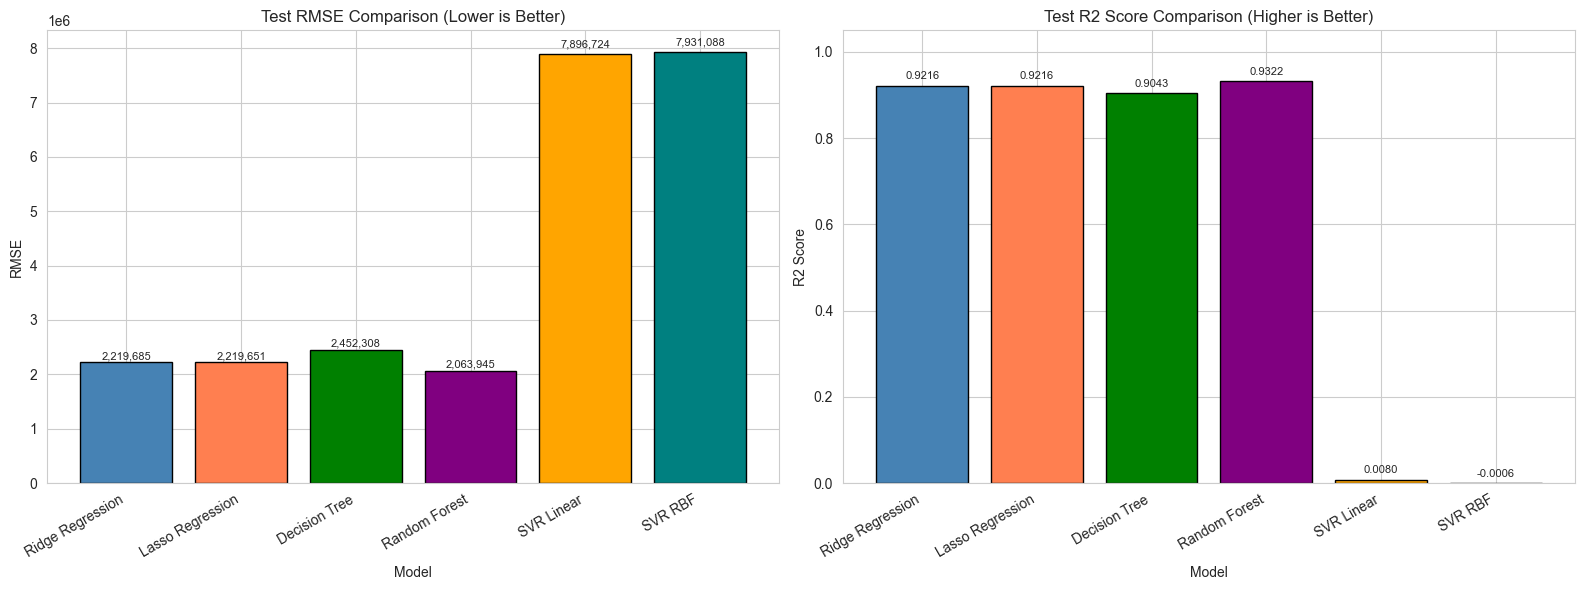

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # comparing all models

models = results_df['Model']
colors = ['steelblue', 'coral', 'green', 'purple', 'orange', 'teal']

bars1 = axes[0].bar(models, results_df['Test RMSE'], color=colors, edgecolor='black')
axes[0].set_title('Test RMSE Comparison (Lower is Better)')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE')
axes[0].set_xticklabels(models, rotation=30, ha='right')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*bar.get_height(),
                f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

bars2 = axes[1].bar(models, results_df['Test R2'], color=colors, edgecolor='black')
axes[1].set_title('Test R2 Score Comparison (Higher is Better)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R2 Score')
axes[1].set_xticklabels(models, rotation=30, ha='right')
axes[1].set_ylim(0, 1.05)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:**
- The Random Forest model achieved the best overall performance with the highest test R² score (0.9322) and the lowest RMSE (2,063,945), making it the most accurate model for house price prediction. Ridge and Lasso Regression also performed well, while both SVR models showed very poor predictive performance with extremely low R² scores and high RMSE values.

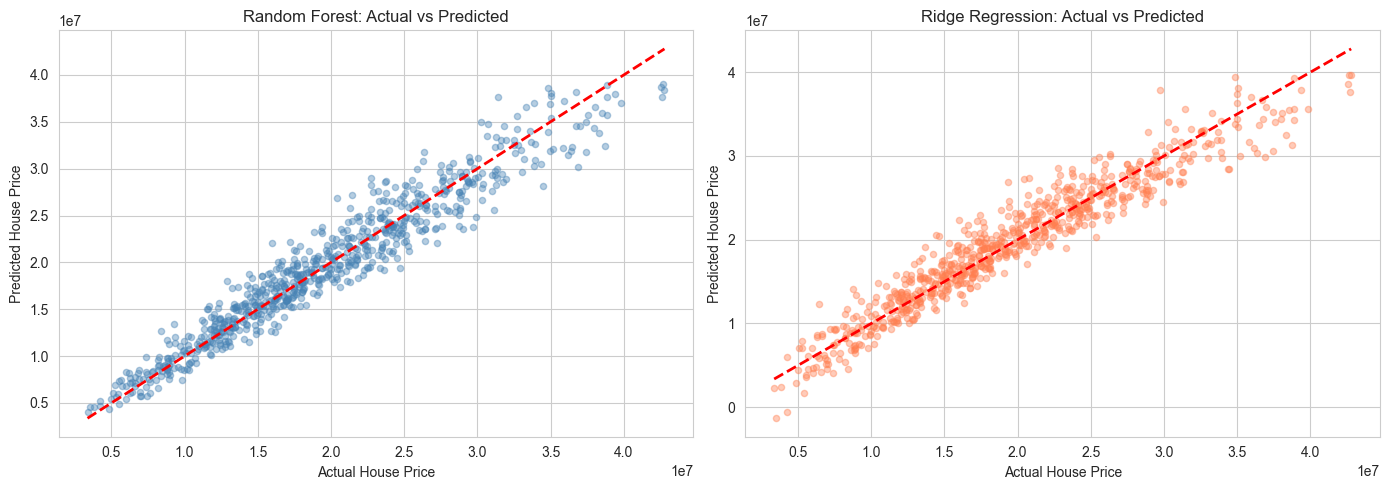

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
axes[0].scatter(y_test, y_pred_rf_test, alpha=0.4, color='steelblue', s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Random Forest: Actual vs Predicted')
axes[0].set_xlabel('Actual House Price')
axes[0].set_ylabel('Predicted House Price')

# Ridge Regression
axes[1].scatter(y_test, y_pred_ridge_test, alpha=0.4, color='coral', s=20)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Ridge Regression: Actual vs Predicted')
axes[1].set_xlabel('Actual House Price')
axes[1].set_ylabel('Predicted House Price')

plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:**
- Both Random Forest and Ridge Regression predict house prices quite well, as most points are close to the red reference line. However, Random Forest predictions are closer to the actual values, showing better accuracy and making it the better model for this dataset.

# Signs of Overfitting or Underfitting

In [67]:
print("Overfitting/Underfitting Analysis:")
print(f"{'Model':<25} {'Train R2':>10} {'Test R2':>10} {'Gap':>10} {'Status':>20}")
print("-" * 80) 

for _, row in results_df.iterrows():
    gap = row['Train R2'] - row['Test R2']
    if gap > 0.15:
        status = 'Overfitting'
    elif row['Test R2'] < 0.5:  
        status = 'Underfitting'
    else:
        status = 'Good Fit'
    print(f"{row['Model']:<25} {row['Train R2']:>10.4f} {row['Test R2']:>10.4f} {gap:>10.4f} {status:>20}")

Overfitting/Underfitting Analysis:
Model                       Train R2    Test R2        Gap               Status
--------------------------------------------------------------------------------
Ridge Regression              0.9133     0.9216    -0.0083             Good Fit
Lasso Regression              0.9133     0.9216    -0.0083             Good Fit
Decision Tree                 0.9392     0.9043     0.0349             Good Fit
Random Forest                 0.9737     0.9322     0.0415             Good Fit
SVR Linear                    0.0059     0.0080    -0.0021         Underfitting
SVR RBF                      -0.0028    -0.0006    -0.0022         Underfitting


# Final Analysis and Reporting

In [69]:
best_model_row = results_df.loc[results_df['Test R2'].idxmax()]
print("Best Performing Model:")
print(best_model_row)

Best Performing Model:
Model         Random Forest
Train RMSE       1326278.59
Test RMSE        2063945.41
Train MAE         999925.68
Test MAE         1595353.48
Train R2             0.9737
Test R2              0.9322
Name: 3, dtype: object


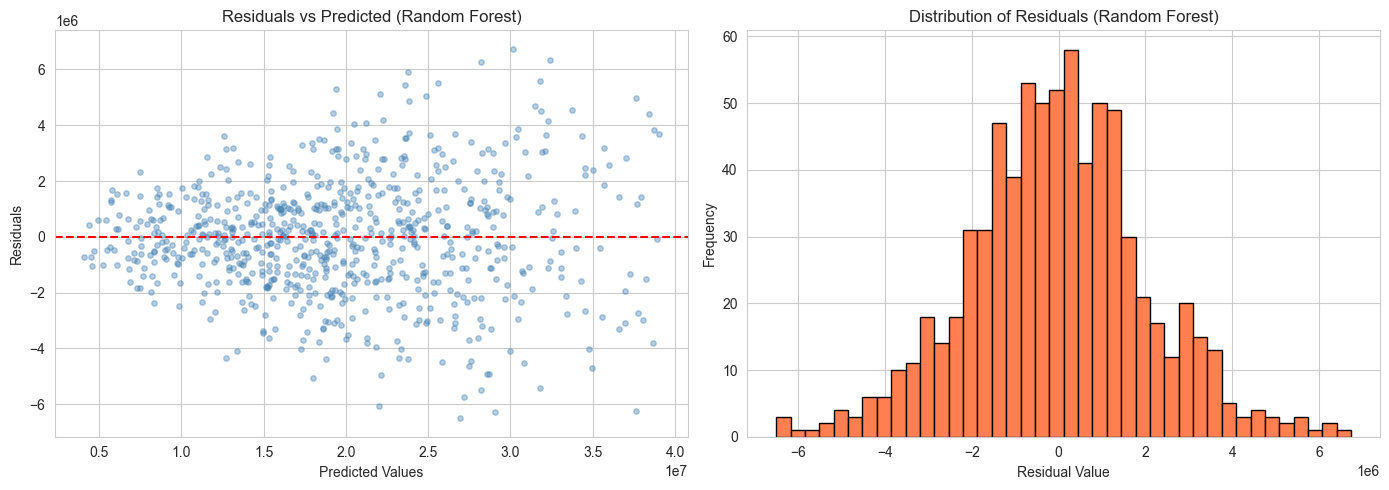

In [70]:
residuals_rf = y_test.values - y_pred_rf_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_rf_test, residuals_rf, alpha=0.4, color='steelblue', s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted (Random Forest)')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

axes[1].hist(residuals_rf, bins=40, color='coral', edgecolor='black')
axes[1].set_title('Distribution of Residuals (Random Forest)')
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('plot_residuals.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:**
- The residuals are randomly scattered around zero, indicating that the Random Forest model does not show any major bias in its predictions. The residual distribution is approximately bell-shaped and centered near zero, suggesting that most prediction errors are small and the model fits the data well.

## Final Conclusions

### 1. Best Performing Model

**Random Forest Regression** is the best performing model in this project. It achieved the highest Test R2 score and the lowest Test RMSE among all models. This is because Random Forest averages the predictions of multiple decision trees, which reduces variance and prevents overfitting that we saw in a single Decision Tree.

### 2. Impact of Regularization

Both Ridge and Lasso regularization helped control overfitting in linear regression. Without regularization, a simple linear model might overfit due to features like bedrooms and bathrooms being correlated. Lasso proved useful for automatic feature selection by zeroing out less important features. Ridge kept all features but with smaller coefficients.

### 3. Role of Cross-Validation in Model Stability

Cross-validation helped us:
- Select the best alpha values for Ridge and Lasso without using the test data.
- Get a more reliable estimate of model performance.
- Compare how stable each CV strategy is (K-Fold was the most stable).

### 4. Linear vs Non-Linear Regressors

Linear models (Ridge, Lasso) gave reasonable but not outstanding results because house price prediction has some non-linear patterns. Tree-based models (especially Random Forest) captured these non-linearities better and gave superior performance. SVR with RBF kernel also performed well due to its ability to model non-linear relationships.

### 5. Business Interpretation

- **Area** is the single most important factor in determining house price.
- **Location quality** is the second most important - invest in prime locations.
- **Distance from city** negatively impacts price - urban properties are more valuable.
- **Crime rate** reduces property values - safety matters to buyers.
- **Metro and school proximity** add a small premium to property prices.